# What are the most demanded skills for the top 3 most popular data roles?

Steps:
1. Clean-up skill column
2. Calculate skill count based on 'job_title_short'
3. Calculate skill percentage
4. Create the plot

In [3]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns
from datasets import load_dataset

#Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [4]:
df_DA_Countries = df[(df['job_country'].isin(['United States', 'Mexico', 'Germany', 'UK']))].copy()

In [5]:
df_skills = df_DA_Countries.explode('job_skills')

In [6]:

df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = df_skills_count.reset_index(name='skill_count') #Converts the series to a dataframe, for easier manipulation
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True) #Sort values based on the skill count from the highest to lowest

df_skills_count

,job_skills,job_title_short,skill_count
1282,python,Data Scientist,48281
1603,sql,Data Analyst,38634
1605,sql,Data Scientist,33777
1604,sql,Data Engineer,30056
483,excel,Data Analyst,29988
...,...,...,...
424,dplyr,Business Analyst,1
1103,ocaml,Data Scientist,1
1104,opencv,Business Analyst,1
1954,xamarin,Data Engineer,1


In [7]:
df_job_title_count = df_DA_Countries['job_title_short'].value_counts().reset_index(name='jobs_total')
df_skills_percent = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')
df_skills_percent['skill_percent'] =  100 * df_skills_percent['skill_count'] / df_skills_percent['jobs_total']
#df_skills_percent = f'{df_skills_percent}%'
df_skills_percent

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,python,Data Scientist,48281,68375,70.612066
1,sql,Data Analyst,38634,77754,49.687476
2,sql,Data Scientist,33777,68375,49.399634
3,sql,Data Engineer,30056,46088,65.214373
4,excel,Data Analyst,29988,77754,38.567791
...,...,...,...,...,...
1971,dplyr,Business Analyst,1,9557,0.010464
1972,ocaml,Data Scientist,1,68375,0.001463
1973,opencv,Business Analyst,1,9557,0.010464
1974,xamarin,Data Engineer,1,46088,0.002170


In [12]:
#Grabs the first 3 values from 'job_title_short' and saves that into a variable
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

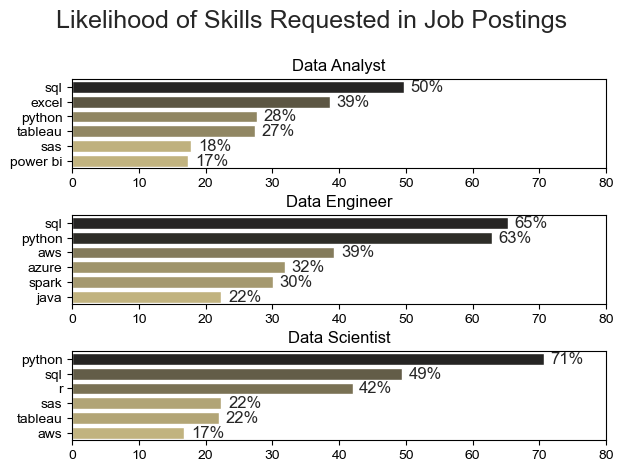

In [9]:
fig, ax = plt.subplots(len(job_titles), 1)

#Set Seaborn Theme
sns.set_theme(style='ticks')


for i, job_title in enumerate(job_titles):
    df_plot = df_skills_percent[df_skills_percent['job_title_short'] == job_title].head(6)
    #Matplotlib chart
    #df_plot.plot(kind='barh', x='job_skills', y='skill_percent', ax=ax[i], title=job_title)
    #Same chart with Seaborn
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:y_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].legend().remove()
    ax[i].set_xlim(0, 80)

    #Loop for showing the % of each skill
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

fig.suptitle('Likelihood of Skills Requested in Job Postings', fontsize=18)
fig.tight_layout(h_pad=0.3)
plt.show()